In [7]:
import json
import matplotlib.pyplot as plt

TRAINING_LOG = "results/sgd_gate_run/training_log.json"
VALUE_WEIGHT = 0.25  # matches train.py default

with open(TRAINING_LOG) as f:
    log = json.load(f)

loss_iters = [e["iteration"] for e in log if e.get("training")]
total_loss  = [e["training"][-1]["total"]  for e in log if e.get("training")]
policy_loss = [e["training"][-1]["policy"] for e in log if e.get("training")]
value_loss  = [e["training"][-1]["value"]  for e in log if e.get("training")]
weighted_value_loss = [VALUE_WEIGHT * v for v in value_loss]

print(f"Parsed {len(loss_iters)} iterations (last: {loss_iters[-1]})")
print(f"Final iter — total: {total_loss[-1]:.3f}  policy: {policy_loss[-1]:.3f}  value: {value_loss[-1]:.3f}")

Parsed 181 iterations (last: 176)
Final iter — total: 1.397  policy: 1.279  value: 0.473


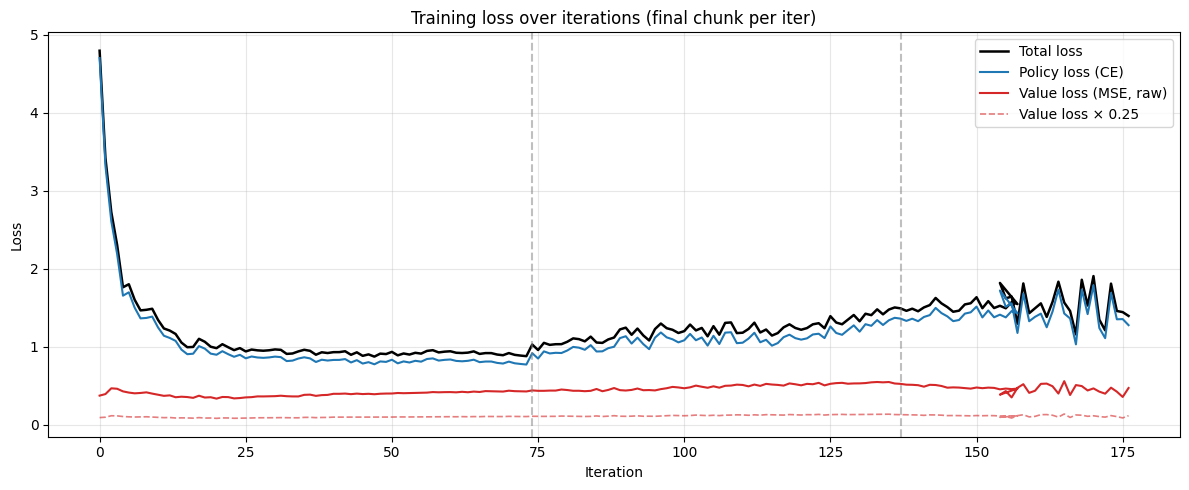

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(loss_iters, total_loss, label="Total loss", linewidth=1.8, color="black")
ax.plot(loss_iters, policy_loss, label="Policy loss (CE)", linewidth=1.5, color="C0")
ax.plot(loss_iters, value_loss, label="Value loss (MSE, raw)", linewidth=1.5, color="C3")
ax.plot(loss_iters, weighted_value_loss, label=f"Value loss \u00d7 {VALUE_WEIGHT}",
        linewidth=1.2, color="C3", linestyle="--", alpha=0.6)
for x in (74, 137):
    ax.axvline(x, color="grey", linestyle="--", alpha=0.5)
ax.set_xlabel("Iteration")
ax.set_ylabel("Loss")
ax.set_title("Training loss over iterations (final chunk per iter)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

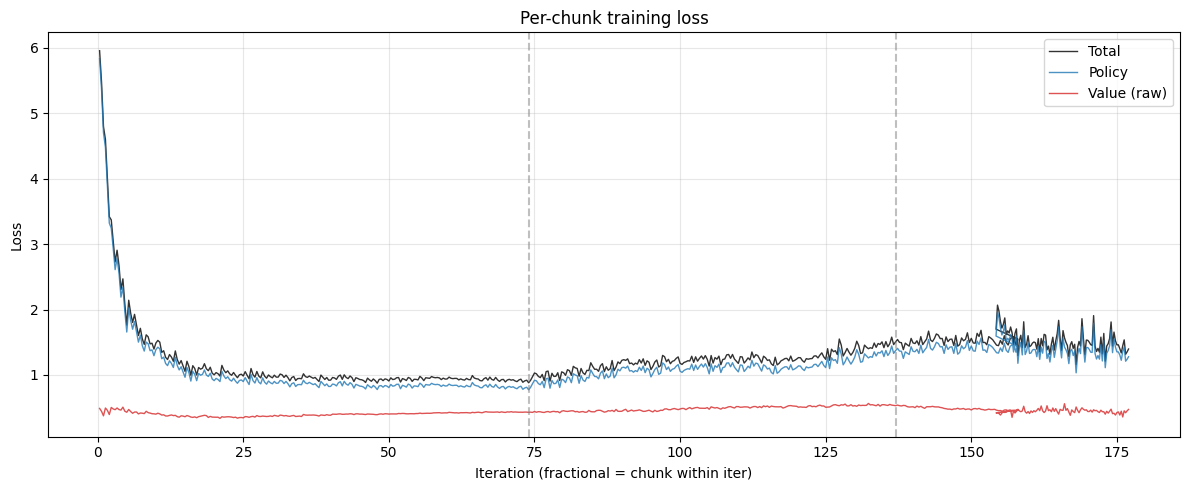

In [9]:
# Higher resolution: every chunk (3 per iter), so within-iter dynamics are visible.
chunk_x, chunk_total, chunk_policy, chunk_value = [], [], [], []
for e in log:
    chunks = e.get("training") or []
    n = len(chunks)
    for i, c in enumerate(chunks):
        chunk_x.append(e["iteration"] + (i + 1) / n)
        chunk_total.append(c["total"])
        chunk_policy.append(c["policy"])
        chunk_value.append(c["value"])

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(chunk_x, chunk_total, label="Total", linewidth=1.0, color="black", alpha=0.8)
ax.plot(chunk_x, chunk_policy, label="Policy", linewidth=1.0, color="C0", alpha=0.8)
ax.plot(chunk_x, chunk_value, label="Value (raw)", linewidth=1.0, color="C3", alpha=0.8)
for x in (74, 137):
    ax.axvline(x, color="grey", linestyle="--", alpha=0.5)
ax.set_xlabel("Iteration (fractional = chunk within iter)")
ax.set_ylabel("Loss")
ax.set_title("Per-chunk training loss")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()